# 04 — Modelos de recomendación: baseline, item-item y SVD

**Autores:** Ezequiel y Franco · **Frente:** Modelos · **Demo 1**

Este notebook reúne todo el modelado del asistente de regalos:

1. Datos y separación temporal (desarrollo 80% / test 20%).
2. Cómo se evalúa un recomendador.
3. Los tres modelos: baseline de popularidad, item-item (KNN por co-compra) y SVD.
4. Validación cruzada temporal para elegir los parámetros de cada modelo (sin tocar el test).
5. Comparación final sobre el test, **una sola vez**, y elección del modelo.

Toda la lógica vive en `src/models/` (`train.py` y `evaluate.py`); este notebook solo la usa.
Las corridas quedan en MLflow, en el experimento del equipo `asistente-regalos-ecommerce`
(base `mlflow.db` en la raíz del repo), separadas por el tag `etapa`: `validacion` (búsqueda de
parámetros) y `test_final` (comparación final). Para verlas, desde la raíz del repo:
`mlflow ui --backend-store-uri sqlite:///mlflow.db`

## 0. Configuración

In [1]:
import sys
from pathlib import Path

RAIZ = Path('..').resolve()          # raíz del repo (este notebook está en notebooks/)
sys.path.append(str(RAIZ))

import pandas as pd
import matplotlib.pyplot as plt

from src.models.evaluate import (cargar_datos_modelo, corte_temporal, construir_casos,
                                 evaluar_cv_temporal, folds_temporales, comparar_modelos)
from src.models.train import Popularidad, ItemItem, SVD
from src.utils.mlflow_utils import registrar_corrida, EXPERIMENTO

RUTA_DATOS = RAIZ / 'data' / 'processed' / 'online_retail_modelo.parquet'
CARPETA_FIGURAS = RAIZ / 'reports' / 'figures'
CARPETA_FIGURAS.mkdir(parents=True, exist_ok=True)

N_FOLDS = 3
SEMILLA = 42
K = 5

## 1. Datos y separación temporal

Se usa `online_retail_modelo.parquet`, que conserva las ventas sin cliente: los modelos solo
necesitan saber qué productos aparecieron juntos en cada factura, no quién compró.

In [2]:
df = cargar_datos_modelo(RUTA_DATOS)
print(f"Filas: {len(df):,} | Facturas: {df['invoice_no'].nunique():,} | Productos: {df['stock_code'].nunique():,}")
print(f"Período: {df['invoice_date'].min():%d/%m/%Y} a {df['invoice_date'].max():%d/%m/%Y}")

# Descripción más frecuente de cada producto, para mostrar recomendaciones con nombre
nombres = df.groupby('stock_code')['description'].agg(lambda s: s.value_counts().idxmax())
def con_nombre(codigos):
    return [f"{c} · {nombres.get(c, '?')}" for c in codigos]

Filas: 991,648 | Facturas: 39,402 | Productos: 4,725
Período: 01/12/2009 a 09/12/2011


El corte es **por fecha y por factura**: el 80% más antiguo de las facturas es desarrollo y el 20%
más reciente es test. Ninguna factura queda partida. **El test solo se usa en la sección 6.**

In [3]:
desarrollo, test, fecha_corte = corte_temporal(df, proporcion_train=0.8)
print(f"Fecha de corte: {fecha_corte:%d/%m/%Y %H:%M}")
print(f"Desarrollo: {desarrollo['invoice_date'].min():%d/%m/%Y} a {desarrollo['invoice_date'].max():%d/%m/%Y} "
      f"({desarrollo['invoice_no'].nunique():,} facturas)")
print(f"Test:       {test['invoice_date'].min():%d/%m/%Y} a {test['invoice_date'].max():%d/%m/%Y} "
      f"({test['invoice_no'].nunique():,} facturas)")

Fecha de corte: 19/08/2011 11:13
Desarrollo: 01/12/2009 a 19/08/2011 (31,521 facturas)
Test:       19/08/2011 a 09/12/2011 (7,881 facturas)


**Hallazgo:** el corte cae el 19/08/2011: el desarrollo tiene 31.521 facturas (dic-2009 a ago-2011)
y el test 7.881 (ago a dic-2011). El test incluye la temporada navideña de 2011, que el modelo
no vio: es una prueba exigente y realista.

## 2. Cómo se evalúa un recomendador

Por cada factura con 2 o más productos se **esconde uno al azar** (con semilla fija) y se le muestra
al modelo otro producto de la misma factura (**modo ancla**, como en la demo, donde el usuario elige
un producto de referencia). El modelo acierta si el producto escondido está entre sus 5 recomendaciones.

| Métrica | Qué mide |
|---|---|
| **Hit Rate@5** (KPI principal) | Porcentaje de casos en que acierta |
| **NDCG@5** | Igual, pero premia que el acierto esté más arriba en la lista |
| **Cobertura** | Qué porcentaje del catálogo llega a recomendar alguna vez |

Solo se evalúan productos que existen en el período de entrenamiento. Ejemplo de casos:

In [4]:
fold_ejemplo = folds_temporales(desarrollo, n_folds=N_FOLDS)[0]
casos_ej, info = construir_casos(fold_ejemplo['valid'], set(fold_ejemplo['train']['stock_code']),
                                 modo='ancla', semilla=SEMILLA)
print(info)
for caso in casos_ej[:3]:
    print(f"\nFactura {caso['factura']}")
    print("  Ancla:  ", con_nombre(caso['anclas']))
    print("  Oculto: ", con_nombre([caso['oculto']]))

{'facturas_evaluadas': 7832, 'facturas_2+_productos': 7078, 'casos': 6970, 'pct_facturas_evaluables': 98.5}

Factura 508993
  Ancla:   ['22617 · BAKING SET SPACEBOY DESIGN']
  Oculto:  ['21129 · SILVER FISHING GNOME']

Factura 508994
  Ancla:   ['21206 · STRAWBERRY HONEYCOMB  GARLAND']
  Oculto:  ['22052 · VINTAGE CARAVAN GIFT WRAP']

Factura 508995
  Ancla:   ['22316 · 200 BENDY SKULL STRAWS']
  Oculto:  ['21716 · BOYS VINTAGE TIN SEASIDE BUCKET']


## 3. Los tres modelos

Los tres parten de la misma **matriz binaria factura × producto** (1 si el producto estuvo en la
factura) y tienen la misma interfaz (`fit`, `recomendar`), así que se comparan en igualdad de condiciones.

### 3.1 Baseline: popularidad

Recomienda siempre los productos que aparecen en más facturas, salvo el que el usuario eligió.
No personaliza nada: es la vara para medir. Si un modelo no le gana, no aporta.

In [5]:
baseline = Popularidad(criterio='facturas').fit(desarrollo)
pd.DataFrame({'producto': con_nombre(baseline.ranking[:10])}, index=range(1, 11))

,producto
1,85123A · WHITE HANGING HEART T-LIGHT HOLDER
2,22423 · REGENCY CAKESTAND 3 TIER
3,85099B · JUMBO BAG RED RETROSPOT
4,21212 · PACK OF 72 RETROSPOT CAKE CASES
5,20725 · LUNCH BAG RED RETROSPOT
6,47566 · PARTY BUNTING
7,84879 · ASSORTED COLOUR BIRD ORNAMENT
8,21232 · STRAWBERRY CERAMIC TRINKET BOX
9,22383 · LUNCH BAG SUKI DESIGN
10,21931 · JUMBO STORAGE BAG SUKI


### 3.2 Item-item: KNN entre productos por co-compra (Ezequiel)

Dos productos son "vecinos" si suelen aparecer en las mismas facturas:

`similitud(A, B) = facturas con A y B juntos / raíz(facturas con A × facturas con B)`

Para el producto elegido se devuelven sus 5 vecinos más cercanos. Los productos con menos de
`min_facturas` facturas no participan, para evitar similitudes altas por casualidad.

### 3.3 SVD: factores latentes (Franco)

El SVD resume cada producto en unos pocos números (`n_components`) que capturan patrones de compra,
y compara productos en ese espacio comprimido. A diferencia del item-item, detecta relaciones
**indirectas**: dos productos que nunca se compraron juntos pero que se compran con los mismos terceros
quedan cerca. El costo es que es menos explicable.

In [6]:
item_item = ItemItem(min_facturas=5).fit(desarrollo)
svd = SVD(n_components=50, min_facturas=5).fit(desarrollo)
print(f"Item-item: {len(item_item.productos):,} productos en el modelo de {item_item.n_productos:,}")
print(f"SVD: {svd.n_componentes_efectivos} componentes, varianza explicada {svd.varianza_explicada:.1%}")

for ancla in baseline.ranking[:3]:
    print(f"\nSi el usuario elige: {con_nombre([ancla])[0]}")
    print(pd.DataFrame({'item-item': con_nombre(item_item.recomendar([ancla], k=K)),
                        'SVD': con_nombre(svd.recomendar([ancla], k=K))},
                       index=range(1, K + 1)).to_string())

Item-item: 4,131 productos en el modelo de 4,456
SVD: 50 componentes, varianza explicada 21.7%

Si el usuario elige: 85123A · WHITE HANGING HEART T-LIGHT HOLDER
                                   item-item                                         SVD
1   21733 · RED HANGING HEART T-LIGHT HOLDER    21733 · RED HANGING HEART T-LIGHT HOLDER
2        82494L · WOODEN FRAME ANTIQUE WHITE     22804 · CANDLEHOLDER PINK HANGING HEART
3  82482 · WOODEN PICTURE FRAME WHITE FINISH  21732 · RED HANGING METAL STAR TLIGHT HLDR
4    22804 · CANDLEHOLDER PINK HANGING HEART            17091A · LAVENDER INCENSE IN TIN
5              22470 · HEART OF WICKER LARGE             17091J · VANILLA INCENSE IN TIN

Si el usuario elige: 22423 · REGENCY CAKESTAND 3 TIER
                                 item-item                                       SVD
1  22697 · GREEN REGENCY TEACUP AND SAUCER   22221 · CAKE STAND LOVEBIRD 2 TIER PINK
2  22699 · ROSES REGENCY TEACUP AND SAUCER               22363 · GLASS JAR MARMA

**Hallazgo:** las recomendaciones tienen sentido para una persona, y los dos modelos se parecen en lo
más obvio pero difieren en lo demás:

- **Item-item** recomienda lo que efectivamente se compra junto, casi siempre de la misma línea de
  producto: para el REGENCY CAKESTAND sugiere las tres tazas Regency; para el WHITE HANGING HEART
  T-LIGHT HOLDER, la versión roja y otros adornos de la misma estética (marcos blancos, corazón de
  mimbre). Es fácil de explicar: "otros clientes lo compraron junto con este".
- **SVD** coincide en el primer puesto cuando la relación es fuerte (RED HANGING HEART, otras JUMBO BAG),
  pero después aparecen relaciones indirectas menos evidentes y a veces ruidosas: para el cakestand
  sugiere otro cakestand y un frasco de mermelada, pero también una pulsera.
- Los dos tienden a sugerir **variantes del mismo producto** (otros colores de la misma bolsa). Para
  un regalo puede ser útil ofrecer alternativas, pero para armar combos conviene diversificar: queda
  para el Sprint 2 (métrica de diversidad y `armar_combos`).

## 4. Validación cruzada temporal: elegir los parámetros de cada modelo

Los parámetros se eligen **sin mirar el test**. Dentro del desarrollo se arman folds expansivos:
siempre se entrena con el pasado y se valida con el período siguiente.

```
fold 1: entrena bloque 1        -> valida bloque 2
fold 2: entrena bloques 1-2     -> valida bloque 3
fold 3: entrena bloques 1-3     -> valida bloque 4
```

Todas las configuraciones se evalúan sobre los mismos casos. Se reporta la media y el desvío entre
folds: si dos configuraciones difieren menos que el desvío, la diferencia no es concluyente.

In [7]:
for f in folds_temporales(desarrollo, n_folds=N_FOLDS):
    print(f"Fold {f['fold']}: entrena {f['fecha_train_desde']:%d/%m/%Y}-{f['fecha_train_hasta']:%d/%m/%Y} "
          f"({f['facturas_train']:,}) | valida {f['fecha_valid_desde']:%d/%m/%Y}-{f['fecha_valid_hasta']:%d/%m/%Y} "
          f"({f['facturas_valid']:,})")

Fold 1: entrena 01/12/2009-19/05/2010 (7,848) | valida 19/05/2010-13/10/2010 (7,832)
Fold 2: entrena 01/12/2009-13/10/2010 (15,680) | valida 13/10/2010-06/03/2011 (7,941)
Fold 3: entrena 01/12/2009-06/03/2011 (23,621) | valida 06/03/2011-19/08/2011 (7,900)


In [8]:
configuraciones = {
    # Baseline
    'popularidad_facturas':    lambda: Popularidad(criterio='facturas'),
    'popularidad_ponderada':   lambda: Popularidad(criterio='ponderada'),
    # Item-item
    'item_item_min3':          lambda: ItemItem(min_facturas=3),
    'item_item_min5':          lambda: ItemItem(min_facturas=5),
    'item_item_min10':         lambda: ItemItem(min_facturas=10),
    'item_item_min5_sin_bulk': lambda: ItemItem(min_facturas=5, excluir_bulk=True),
    'item_item_min5_tope200':  lambda: ItemItem(min_facturas=5, max_productos_factura=200),
    # SVD
    'svd_n20':                 lambda: SVD(n_components=20),
    'svd_n50':                 lambda: SVD(n_components=50),
    'svd_n100':                lambda: SVD(n_components=100),
    'svd_n50_tope200':         lambda: SVD(n_components=50, max_productos_factura=200),
}

def familia(nombre):
    return nombre.split('_')[0] if nombre.startswith(('popularidad', 'svd')) else 'item_item'

# Cada configuración queda registrada en MLflow (etapa=validacion) con sus parámetros,
# la media y el desvío de cada métrica, y su familia de modelo
etiquetas = {n: {'familia': familia(n)} for n in configuraciones}
detalle, resumen = evaluar_cv_temporal(desarrollo, configuraciones, n_folds=N_FOLDS,
                                       k=K, modo='ancla', semilla=SEMILLA,
                                       registrar_mlflow=True, tags={'notebook': '04'},
                                       tags_por_modelo=etiquetas)
resumen['familia'] = resumen['modelo'].map(familia)

columnas = ['familia', 'modelo', 'hit_rate_at_5_media', 'hit_rate_at_5_std', 'ndcg_at_5_media', 'cobertura_catalogo_media']
resumen[columnas].round(3)

2026/10/10 19:59:27 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/10/10 19:59:27 INFO mlflow.store.db.utils: Updating database tables


,familia,modelo,hit_rate_at_5_media,hit_rate_at_5_std,ndcg_at_5_media,cobertura_catalogo_media
0,item_item,item_item_min5_tope200,0.094,0.005,0.066,0.672
1,item_item,item_item_min5_sin_bulk,0.091,0.005,0.064,0.641
2,item_item,item_item_min3,0.091,0.005,0.064,0.666
3,item_item,item_item_min5,0.091,0.005,0.064,0.645
4,item_item,item_item_min10,0.090,0.005,0.064,0.599
5,svd,svd_n50_tope200,0.077,0.003,0.055,0.577
6,svd,svd_n100,0.075,0.003,0.054,0.597
7,svd,svd_n50,0.074,0.002,0.053,0.586
8,svd,svd_n20,0.067,0.003,0.047,0.607
9,popularidad,popularidad_facturas,0.032,0.001,0.021,0.002


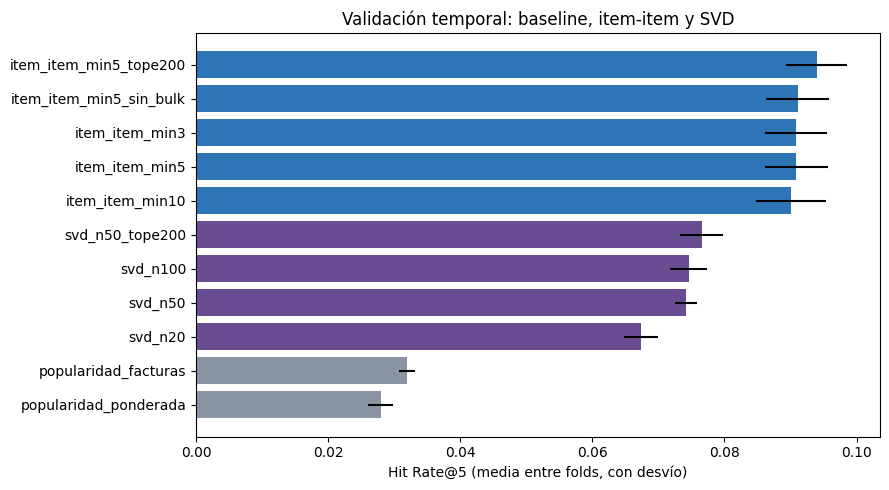

In [9]:
colores = {'popularidad': '#8A94A3', 'item_item': '#2E75B6', 'svd': '#6A4C93'}
orden = resumen.sort_values('hit_rate_at_5_media')
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(orden['modelo'], orden['hit_rate_at_5_media'], xerr=orden['hit_rate_at_5_std'],
        color=orden['familia'].map(colores))
ax.set_xlabel('Hit Rate@5 (media entre folds, con desvío)')
ax.set_title('Validación temporal: baseline, item-item y SVD')
plt.tight_layout()
plt.savefig(CARPETA_FIGURAS / '04_validacion_modelos.png', dpi=120)
plt.show()

### Mejor configuración de cada modelo

In [10]:
# La mejor de cada familia por Hit Rate medio. Si la diferencia con la siguiente es menor que el
# desvío, conviene preferir la más simple (se puede cambiar a mano en ELEGIDOS).
mejores = resumen.sort_values('hit_rate_at_5_media', ascending=False).groupby('familia').head(1)
ELEGIDOS = dict(zip(mejores['familia'], mejores['modelo']))
print(ELEGIDOS)
mejores[columnas].round(3)

{'item_item': 'item_item_min5_tope200', 'svd': 'svd_n50_tope200', 'popularidad': 'popularidad_facturas'}


,familia,modelo,hit_rate_at_5_media,hit_rate_at_5_std,ndcg_at_5_media,cobertura_catalogo_media
0,item_item,item_item_min5_tope200,0.094,0.005,0.066,0.672
5,svd,svd_n50_tope200,0.077,0.003,0.055,0.577
9,popularidad,popularidad_facturas,0.032,0.001,0.021,0.002


**Hallazgo:** el item-item es claramente el mejor modelo en validación: **9,1% a 9,4% de Hit Rate@5**
según la configuración, contra **7,4% a 7,7% del SVD** y **3,2% del baseline** (casi 3 veces mejor),
con desvíos entre folds de 0,005 o menos. Es el único que además sostiene una cobertura alta del
catálogo (64% a 67%; el baseline recomienda siempre lo mismo y cubre el 0,2%). Dentro de cada familia,
las variantes difieren poco:

- **Item-item:** min 3, 5 y 10 dan prácticamente lo mismo (9,0% a 9,1%); min 10 pierde cobertura (60%).
  Se queda **min_facturas = 5**.
- **Baseline:** el criterio por facturas (3,2%) supera al ponderado de la guía (2,8%) por más que el
  desvío. Se queda **criterio = "facturas"**.

**Decisión sobre facturas bulk y facturas gigantes:** **no se excluyen las facturas bulk** (sin bulk da
el mismo 9,1% y baja la cobertura de 64,5% a 64,1%), pero **sí se ignoran las facturas con más de 200
productos distintos** al entrenar (`max_productos_factura=200`). La mejora es chica (9,4% contra 9,1%,
menor que el desvío de 0,005), pero se repite en la misma dirección en los dos modelos (también en el
SVD: 7,7% contra 7,4%), sube la cobertura (67,2% contra 64,5%) y el NDCG, y tiene sentido de negocio:
una factura de reposición de medio catálogo junta productos sin relación entre sí. No agrega
complejidad: es un parámetro.

**Decisión sobre `n_components` del SVD:** **50 componentes**. Con 20 el Hit Rate cae a 6,7% (una
diferencia mayor que el desvío); con 100 da 7,5% contra 7,4% de 50, dentro del desvío, con el doble
de tamaño. Con 50 componentes el SVD explica el 21,7% de la varianza de la matriz.

### Referencia: modo carrito

Las configuraciones elegidas, evaluadas con los mismos folds pero viendo todos los demás productos de
la factura. Quedan registradas en MLflow con el sufijo `_carrito` (parámetro `modo=carrito`).
No se usan para elegir parámetros: el modo principal es ancla.

In [11]:
elegidos_carrito = {f'{n}_carrito': configuraciones[n] for n in ELEGIDOS.values()}
_, resumen_carrito = evaluar_cv_temporal(desarrollo, elegidos_carrito, n_folds=N_FOLDS, k=K,
                                         modo='carrito', semilla=SEMILLA,
                                         registrar_mlflow=True, tags={'notebook': '04', 'referencia': 'carrito'},
                                         tags_por_modelo={n: {'familia': familia(n)} for n in elegidos_carrito})
resumen_carrito[columnas[1:]].round(3)

,modelo,hit_rate_at_5_media,hit_rate_at_5_std,ndcg_at_5_media,cobertura_catalogo_media
0,item_item_min5_tope200_carrito,0.208,0.007,0.149,0.465
1,svd_n50_tope200_carrito,0.094,0.008,0.066,0.491
2,popularidad_facturas_carrito,0.033,0.000,0.022,0.005


### Registro de la validación en MLflow

Las corridas ya quedaron registradas al llamar a `evaluar_cv_temporal(..., registrar_mlflow=True)`:
una por configuración, en el experimento `asistente-regalos-ecommerce` con `etapa=validacion`.
En la interfaz de MLflow se filtran con `tags.etapa = "validacion"`; ahí está la justificación
con números de cada parámetro elegido (por ejemplo, el `n_components` del SVD).

Las corridas en modo carrito llevan además el tag `referencia=carrito`.

## 5. Reentrenar los elegidos con todo el desarrollo

Con los parámetros ya elegidos, cada modelo se entrena con **todo** el desarrollo (no solo con un fold),
para que aprenda de la mayor cantidad de datos antes de la evaluación final.

In [12]:
modelos_finales = {familia: configuraciones[nombre]().fit(desarrollo) for familia, nombre in ELEGIDOS.items()}
{familia: m.get_params() for familia, m in modelos_finales.items()}

{'item_item': {'modelo': 'item_item',
  'min_facturas': 5,
  'max_productos_factura': 200,
  'excluir_bulk': False,
  'completar_con_popularidad': True},
 'svd': {'modelo': 'svd',
  'n_components': 50,
  'min_facturas': 5,
  'max_productos_factura': 200,
  'excluir_bulk': False,
  'completar_con_popularidad': True,
  'random_state': 42},
 'popularidad': {'modelo': 'popularidad', 'criterio': 'facturas'}}

## 6. Comparación final sobre el test (una sola vez)

Los casos del test se arman **una vez** y los tres modelos se evalúan sobre exactamente los mismos.
Esta es la cifra que se reporta en la demo y en el informe. Queda registrada en
MLflow con `etapa=test_final`: una corrida por modelo (con el modelo entrenado guardado como
artefacto) y una de resumen con la tabla y el gráfico.

Como referencia, los mismos modelos también se evalúan en modo carrito sobre el test (columna
`hit_rate_at_5_carrito` de la tabla).

In [13]:
casos_test, info_test = construir_casos(test, set(desarrollo['stock_code']), modo='ancla', semilla=SEMILLA)
print(info_test)

etiquetas_finales = {f: {'familia': f, 'configuracion': ELEGIDOS[f]} for f in modelos_finales}
tabla_final = comparar_modelos(modelos_finales, casos_test, k=K,
                               params_comunes={'fecha_corte': str(fecha_corte), 'modo': 'ancla'},
                               tags={'notebook': '04'}, tags_por_modelo=etiquetas_finales,
                               guardar_modelos=True)
# Referencia en modo carrito sobre el mismo test (no cambia la elección del modelo)
casos_test_carrito, _ = construir_casos(test, set(desarrollo['stock_code']), modo='carrito', semilla=SEMILLA)
tabla_carrito = comparar_modelos({f'{f}_carrito': m for f, m in modelos_finales.items()}, casos_test_carrito, k=K,
                                 params_comunes={'fecha_corte': str(fecha_corte), 'modo': 'carrito'},
                                 tags={'notebook': '04', 'referencia': 'carrito'},
                                 tags_por_modelo={f'{f}_carrito': {'familia': f} for f in modelos_finales})
tabla_final['hit_rate_at_5_carrito'] = (tabla_final['modelo'] + '_carrito').map(
    tabla_carrito.set_index('modelo')['hit_rate_at_5'])
tabla_final.round(3)

{'facturas_evaluadas': 7881, 'facturas_2+_productos': 7348, 'casos': 7190, 'pct_facturas_evaluables': 97.8}


,modelo,hit_rate_at_5,ndcg_at_5,cobertura_catalogo,casos,hit_rate_at_5_carrito
0,item_item,0.084,0.059,0.616,7190,0.199
1,svd,0.070,0.048,0.535,7190,0.070
2,popularidad,0.018,0.011,0.001,7190,0.023


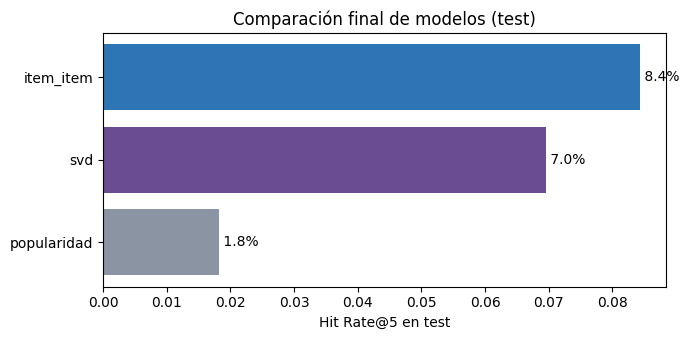

Corridas registradas en el experimento 'asistente-regalos-ecommerce'


In [14]:
fig, ax = plt.subplots(figsize=(7, 3.5))
orden = tabla_final.sort_values('hit_rate_at_5')
ax.barh(orden['modelo'], orden['hit_rate_at_5'], color=orden['modelo'].map(colores))
for i, v in enumerate(orden['hit_rate_at_5']):
    ax.text(v, i, f" {v:.1%}", va='center')
ax.set_xlabel('Hit Rate@5 en test')
ax.set_title('Comparación final de modelos (test)')
plt.tight_layout()
ruta_grafico = CARPETA_FIGURAS / '04_comparacion_final.png'
ruta_tabla = RAIZ / 'reports' / 'comparacion_modelos.csv'
plt.savefig(ruta_grafico, dpi=120)
plt.show()
tabla_final.to_csv(ruta_tabla, index=False)

# Tabla y gráfico como artefactos de MLflow, en una corrida de resumen
registrar_corrida('resumen_comparacion',
                  parametros={'fecha_corte': str(fecha_corte), 'modo': 'ancla', 'k': K,
                              'elegidos': ', '.join(ELEGIDOS.values())},
                  metricas={f'hit_rate_at_{K}_{fila.modelo}': fila[f'hit_rate_at_{K}']
                            for _, fila in tabla_final.iterrows()},
                  tags={'etapa': 'test_final', 'notebook': '04'},
                  artefactos=[ruta_tabla, ruta_grafico])
print(f"Corridas registradas en el experimento '{EXPERIMENTO}'")

## 7. Conclusión

**Resultados en test** (7.190 casos, agosto a diciembre de 2011, que ningún modelo vio):

| Modelo | Hit Rate@5 | NDCG@5 | Cobertura | Hit Rate@5 carrito (ref.) |
|---|---|---|---|---|
| Item-item (min 5, tope 200) | **8,4%** | **0,059** | **61,6%** | **19,9%** |
| SVD (50 componentes, tope 200) | 7,0% | 0,048 | 53,5% | 7,0% |
| Popularidad (baseline) | 1,8% | 0,011 | 0,1% | 2,3% |

**Modelo elegido: item-item (KNN por co-compra), con `min_facturas=5` y `max_productos_factura=200`.**

**Por qué:**
1. **Hit Rate@5 en test:** 8,4%, el mejor de los tres y **más de 4 veces el baseline** (1,8%). El orden es
   el mismo que en la validación, así que la elección no depende de un período en particular.
2. **NDCG@5:** también el mejor (0,059): cuando acierta, el producto aparece más arriba en la lista.
3. **Cobertura:** recomienda el 61,6% del catálogo, contra el 53,5% del SVD y el 0,1% del baseline.
4. **Explicabilidad:** se explica en una frase ("otros clientes lo compraron junto con este"), algo
   importante para mostrarle al usuario por qué se le sugiere cada regalo.
5. **Modo carrito:** con varios productos a la vista llega al 19,9%, casi el triple que el SVD. Es la
   base natural para `armar_combos`.

El SVD queda documentado como alternativa: encuentra relaciones indirectas, pero en estos datos no
supera al item-item en ninguna métrica.

**Sobre el test:** todos los modelos rinden un poco menos que en validación (item-item 9,4% → 8,4%;
baseline 3,2% → 1,8%). Es esperable: el test incluye la temporada navideña de 2011, con productos y
patrones de compra nuevos. La caída fuerte del baseline muestra que "lo más vendido" cambia con la
temporada, y refuerza la idea de recomendar por co-compra.

**Limitaciones:** el sistema aprende de comportamiento de compra (feedback implícito), no de satisfacción;
los datos son de 2009-2011; las métricas son offline y la adopción real se validaría con un test A/B.

**Qué sigue (Sprint 2):** decisión sobre mayoristas (Hit Rate en compras no mayoristas), métricas finales
(incluida la diversidad, para no sugerir solo variantes del mismo producto), `buscar_ideas_regalo`,
`armar_combos` y `modelo_final.pkl`.